# StatsForecast with synthetic data

StatsForecast fits each series independently, so synthetic data plays a different role here than it does for global models. This guide establishes three things in order: augmenting a panel cannot change a local fit, there is no local-model equivalent of pretraining, and a generated series with a known process makes a good pipeline check.


`AutoETS` and its siblings share no parameters across series. Everything below follows from that.


We use the classic [Box–Jenkins airline passenger series](https://search.r-project.org/R/refmans/datasets/html/AirPassengers.html). Its final 12 months are held out before `SynAugment` analyzes the training history.

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsforecast import StatsForecast
from statsforecast.models import AutoETS, SeasonalNaive

from utilsforecast.evaluation import evaluate
from utilsforecast.losses import mae

from synforecast import SynAugment
from synforecast.generators import ETSGenerator


In [ ]:
HORIZON = 12
TARGET_ID = "AirPassengers"
data_path = Path("nbs/data/air_passengers.csv")
if not data_path.exists():
    data_path = Path("../../data/air_passengers.csv")

observed_df = pd.read_csv(data_path, parse_dates=["ds"])
train_df = observed_df.iloc[:-HORIZON].copy()
test_df = observed_df.iloc[-HORIZON:].copy()
train_df.tail()

,unique_id,ds,y
127,AirPassengers,1959-08-31,559.0
128,AirPassengers,1959-09-30,463.0
129,AirPassengers,1959-10-31,407.0
130,AirPassengers,1959-11-30,362.0
131,AirPassengers,1959-12-31,405.0


## 1. Augmentation cannot change a local fit

Adding synthetic series gives `AutoETS` more series to fit, but no pooled parameter for them to influence, so the model fitted to the airline series is untouched. Sixteen `SynAugment` counterparts are added under a SARIMA override; the 12-month holdout is removed first, so no future value reaches the augmenter.


In [ ]:
augmented_train_df = SynAugment(seed=42).augment(
    train_df,
    n_augment=16,
    generator_override={TARGET_ID: "SARIMAGenerator"},
)

pd.DataFrame(
    {
        "training set": ["observed only", "observed + augmented"],
        "series": [1, augmented_train_df["unique_id"].nunique()],
    }
)


,training set,series
0,observed only,1
1,observed + augmented,17


In [ ]:
def make_forecaster() -> StatsForecast:
    return StatsForecast(
        models=[AutoETS(season_length=12)],
        freq="ME",
        n_jobs=1,
    )


def target_forecast(forecast_df: pd.DataFrame) -> pd.DataFrame:
    return forecast_df.loc[
        forecast_df["unique_id"].astype(str) == TARGET_ID,
        ["unique_id", "ds", "AutoETS"],
    ].copy()

In [ ]:
real_only = make_forecaster()
real_only.fit(train_df)
real_only_forecast = target_forecast(real_only.predict(h=HORIZON))

In [ ]:
with_augmentation = make_forecaster()
with_augmentation.fit(augmented_train_df)
augmented_forecast = target_forecast(with_augmentation.predict(h=HORIZON))

identical = np.allclose(
    real_only_forecast["AutoETS"], augmented_forecast["AutoETS"]
)
print(f"the two forecasts are identical: {identical}")


the two forecasts are identical: True


In [ ]:
forecast_sets = {
    "Observed only": real_only_forecast,
    "Observed + synthetic panel": augmented_forecast,
}
comparison = test_df[["unique_id", "ds", "y"]].copy()
for label, forecast_df in forecast_sets.items():
    comparison = comparison.merge(
        forecast_df.rename(columns={"AutoETS": label}),
        on=["unique_id", "ds"],
        how="left",
    )

scores = evaluate(comparison, metrics=[mae], models=list(forecast_sets))
metrics = scores.melt(
    id_vars=["unique_id", "metric"], var_name="workflow", value_name="MAE"
).loc[:, ["workflow", "MAE"]]
metrics


,workflow,MAE
0,Observed only,35.612471
1,Observed + synthetic panel,35.612471


Both workflows score the same because they *are* the same fit. In the chart the augmented forecast is drawn as a thick translucent band with the observed-only line on top of it — one visible line means the two coincide exactly.


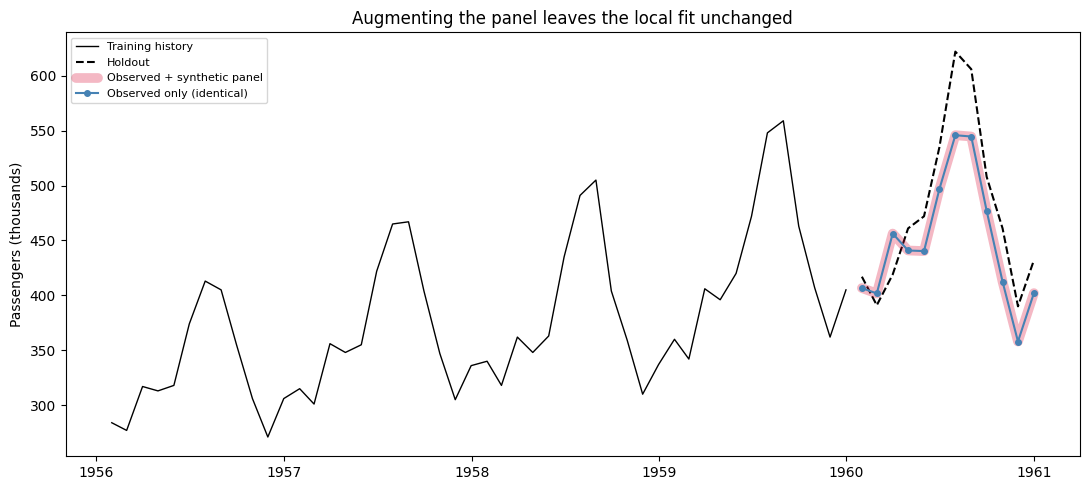

In [ ]:
fig, ax = plt.subplots(figsize=(11, 5))
history = train_df.tail(48)
ax.plot(history["ds"], history["y"], color="black", linewidth=1, label="Training history")
ax.plot(test_df["ds"], test_df["y"], color="black", linestyle="--", label="Holdout")
# The two forecasts are identical, so the augmented one is drawn wide and
# translucent with the observed-only line on top of it.
ax.plot(comparison["ds"], comparison["Observed + synthetic panel"],
        color="crimson", linewidth=7, alpha=0.3, solid_capstyle="round",
        label="Observed + synthetic panel")
ax.plot(comparison["ds"], comparison["Observed only"],
        color="steelblue", linewidth=1.5, marker="o", markersize=4,
        label="Observed only (identical)")
ax.set(title="Augmenting the panel leaves the local fit unchanged",
       ylabel="Passengers (thousands)")
ax.legend(fontsize=8)
fig.tight_layout()


## 2. There is no local-model pretraining

Because nothing is shared, fitting `AutoETS` to synthetic histories produces forecasts *for those histories*, not for the airline series. Averaging them is not a shortcut either, and the table below shows why: `SynAugment` matches each draw to the **mean of the training window**, which leaves the final level free. On a strongly trending series the two are far apart, so the draws end scattered around the observed endpoint.


In [ ]:
synthetic_history_df = augmented_train_df.loc[
    augmented_train_df["unique_id"].astype(str) != TARGET_ID
].copy()

levels = synthetic_history_df.groupby("unique_id", observed=True)["y"].agg(
    window_mean="mean",
    final_year_mean=lambda values: values.tail(12).mean(),
)

pd.DataFrame(
    {
        "series": ["observed", "synthetic (16 draws)"],
        "window mean": [
            round(train_df["y"].mean(), 1),
            f"{levels['window_mean'].min():.0f} - {levels['window_mean'].max():.0f}",
        ],
        "final-year mean": [
            round(train_df["y"].tail(12).mean(), 1),
            f"{levels['final_year_mean'].min():.0f} - {levels['final_year_mean'].max():.0f}",
        ],
    }
)


,series,window mean,final-year mean
0,observed,262.5,428.3
1,synthetic (16 draws),262 - 263,191 - 506


## 3. Validate the pipeline on a known process

The two sections above used the airline series, whose true process nobody knows. A generated series is different: you chose the process, the seasonal period, and the noise scale, so you know in advance what a correctly configured pipeline should be able to do.

That makes it a check with a known answer. The twelve series below come from an additive ETS process with a 12-period season, and the last 12 points of each are held out. `AutoETS` should beat `SeasonalNaive` by a wide margin, because the data really does contain the smooth trend-plus-season structure `AutoETS` fits and `SeasonalNaive` ignores. If it does not, the pipeline is misconfigured — and you have learned that without touching real data.


In [ ]:
NOISE_STD = 6.0
known_process = ETSGenerator(
    min_length=132,
    max_length=132,
    freq="ME",
    engine="polars",
    seasonal_period=12,
    error_type="add",
    trend_type="add",
    seasonal_type="add",
    level=300.0,
    trend=1.5,
    noise_std=NOISE_STD,
    seed=7,
)
known_panel = known_process.generate(n_series=12).to_pandas()

is_holdout = (
    known_panel.groupby("unique_id", observed=True).cumcount() >= 132 - HORIZON
)
known_train_df = known_panel.loc[~is_holdout]
known_test_df = known_panel.loc[is_holdout]

known_models = StatsForecast(
    models=[AutoETS(season_length=12), SeasonalNaive(season_length=12)],
    freq="ME",
    n_jobs=1,
)
known_models.fit(known_train_df)
known_forecast = known_models.predict(h=HORIZON).merge(
    known_test_df[["unique_id", "ds", "y"]], on=["unique_id", "ds"]
)

known_scores = evaluate(
    known_forecast,
    metrics=[mae],
    models=["AutoETS", "SeasonalNaive"],
    agg_fn="mean",
)

known_scores.melt(id_vars="metric", var_name="model", value_name="MAE").loc[
    :, ["model", "MAE"]
].round(2)


,model,MAE
0,AutoETS,11.52
1,SeasonalNaive,49.54


`AutoETS` comes in around four times more accurate than `SeasonalNaive`, which is the outcome the generated structure predicts. That is the whole check: a known-answer test that fails loudly when the frequency, the season length, or the model family is set up wrongly.

For a sense of how much of the remaining error is irreducible, the noise is Gaussian with standard deviation `NOISE_STD`, so the best any forecaster could do one step ahead is a mean absolute error of `NOISE_STD * sqrt(2 / pi)`. Forecasting twelve steps ahead must do worse than that, since an additive-error ETS accumulates innovations into its state as the horizon grows — so treat the number below as a lower bound to sit above, not a target to reach.


In [ ]:
best_one_step_mae = NOISE_STD * np.sqrt(2 / np.pi)
print(f"generator noise standard deviation: {NOISE_STD:.2f}")
print(f"best possible one-step MAE:         {best_one_step_mae:.2f}")


generator noise standard deviation: 6.00
best possible one-step MAE:         4.79


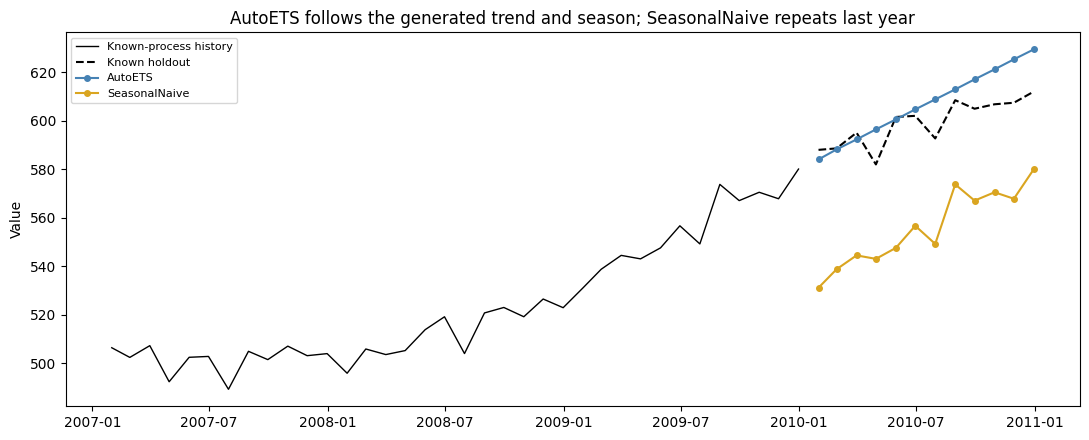

In [ ]:
example_id = known_panel["unique_id"].iloc[0]
example_history = known_train_df.loc[known_train_df["unique_id"] == example_id].tail(36)
example_holdout = known_test_df.loc[known_test_df["unique_id"] == example_id]
example_forecast = known_forecast.loc[known_forecast["unique_id"] == example_id]

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(example_history["ds"], example_history["y"], color="black", linewidth=1,
        label="Known-process history")
ax.plot(example_holdout["ds"], example_holdout["y"], color="black", linestyle="--",
        label="Known holdout")
ax.plot(example_forecast["ds"], example_forecast["AutoETS"], color="steelblue",
        marker="o", markersize=4, label="AutoETS")
ax.plot(example_forecast["ds"], example_forecast["SeasonalNaive"], color="goldenrod",
        marker="o", markersize=4, label="SeasonalNaive")
ax.set(
    title="AutoETS follows the generated trend and season; SeasonalNaive repeats last year",
    ylabel="Value",
)
ax.legend(fontsize=8)
fig.tight_layout()


For local models, synthetic data is a test instrument rather than extra training signal. Augmentation is inert, aggregating synthetic fits is not a substitute for pretraining, and generating from a process you configured yourself gives you a check whose answer you already know.

Panel augmentation does help model families that pool parameters across series — see the [MLForecast](mlforecast) and [NeuralForecast](neuralforecast) guides. Synthetic panels are also useful here for stress testing: inject [anomalies](../capabilities/anomalies) or [changepoints](../capabilities/changepoints) with known positions and measure how far the fitted model moves.
